# Main baseline-method comparison figure

A one-column paper figure showing the raw ASAS-SN light curve followed by residual light curves from a global biweight baseline, a per-camera rolling median, an unmasked per-camera GP, and the production masked per-camera GP. Each baseline is scored independently by the production event detector; red crosses mark the dip or jump event indices returned for that baseline.

In [1]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.stats import biweight_location
from IPython.display import display

candidate_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next(
    (p for p in candidate_roots if (p / 'pyproject.toml').is_file() and (p / 'malca' / 'core' / 'baseline.py').is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError(f'Could not find the MALCA repository above {Path.cwd()}')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from malca.core.baseline import (
    per_camera_gp_baseline,
    per_camera_gp_baseline_masked,
    per_camera_median_baseline,
)
from malca.core.utils import clean_lc
from malca.io.lightcurve_io import load_lightcurve_df, to_asassn_algorithm_frame
from malca.plotting.lightcurve_publication import FIG_SINGLE_COL_WIDTH, PUBLICATION_STYLE, finalize_publication_figure
from malca.stv.events import DEFAULT_BASELINE_KWARGS, score_events_bayesian

TARGET_ID = '214748665650'
JD_OFFSET = 2458000.0
RUN_ROOT = repo_root / 'output' / 'runs' / 'dat3-full-extended_2026-07-01-v4'
RUN_PARAMS = json.loads((RUN_ROOT / 'run_params.json').read_text())
LIGHTCURVE_PATH = RUN_ROOT / 'bundle_assets' / 'lightcurves' / f'{TARGET_ID}.dat3'
OUTPUT_DIR = repo_root / 'output' / 'pdf' / 'baseline_methods' / 'illustrative'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = OUTPUT_DIR / f'baseline_residual_methods_{TARGET_ID}_g.pdf'
PNG_PATH = OUTPUT_DIR / f'baseline_residual_methods_{TARGET_ID}_g.png'


In [2]:
def robust_scatter(values):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    center = np.median(values)
    return float(1.4826 * np.median(np.abs(values - center)))

def global_biweight_baseline(frame, *, c=6.0):
    result = frame.copy().reset_index(drop=True)
    mag = pd.to_numeric(result['mag'], errors='coerce').to_numpy(float)
    error = pd.to_numeric(result['error'], errors='coerce').to_numpy(float)
    finite = np.isfinite(mag)
    if not finite.any():
        raise ValueError('No finite magnitudes for the global biweight baseline.')
    center = float(biweight_location(mag[finite], c=c))
    result['baseline'] = center
    result['resid'] = mag - center
    scatter = robust_scatter(result['resid'])
    error_median = float(np.nanmedian(error[np.isfinite(error) & (error > 0)]))
    error_safe = np.where(np.isfinite(error) & (error > 0), error, error_median)
    robust_std = max(float(np.sqrt(scatter ** 2 + error_median ** 2)), 1e-6)
    result['sigma_resid'] = result['resid'] / robust_std
    result['sigma_eff'] = np.maximum(np.sqrt(error_safe ** 2 + scatter ** 2), 1e-6)
    result['baseline_source'] = 'global_biweight'
    return result

EVENT_SCORING_KWARGS = {
    'p_points': int(RUN_PARAMS['p_points']),
    'mag_points': int(RUN_PARAMS['mag_points']),
    'trigger_mode': str(RUN_PARAMS['trigger_mode']),
    'significance_threshold': float(RUN_PARAMS['significance_threshold']),
    'run_min_points': int(RUN_PARAMS['run_min_points']),
    'max_gap_points': int(RUN_PARAMS['run_max_gap_points']),
    'run_max_gap_days': RUN_PARAMS['run_max_gap_days'],
    'run_min_duration_days': RUN_PARAMS['run_min_duration_days'],
    'compute_event_prob': True,
}

def production_event_mask(lightcurve, baseline_result):
    indices_by_kind = {}
    for kind in ('dip', 'jump'):
        score = score_events_bayesian(
            lightcurve,
            kind=kind,
            baseline_func=None,
            df_base=baseline_result,
            logbf_threshold=float(RUN_PARAMS[f'logbf_threshold_{kind}']),
            **EVENT_SCORING_KWARGS,
        )
        indices_by_kind[kind] = np.asarray(score['event_indices'], dtype=int)
    event_mask = np.zeros(len(lightcurve), dtype=bool)
    combined = np.concatenate(list(indices_by_kind.values()))
    if combined.size:
        event_mask[np.unique(combined)] = True
    return event_mask, indices_by_kind

canonical = load_lightcurve_df(LIGHTCURVE_PATH, apply_quality=True)
cleaned = clean_lc(to_asassn_algorithm_frame(canonical)).reset_index(drop=True)
bands = pd.to_numeric(cleaned['v_g_band'], errors='coerce')
lightcurve = cleaned.loc[np.isclose(bands, 0.0)].copy().reset_index(drop=True)
if lightcurve.empty:
    raise ValueError(f'No g-band data found for {TARGET_ID}.')

production = per_camera_gp_baseline_masked(lightcurve, **DEFAULT_BASELINE_KWARGS).reset_index(drop=True)
baseline_results = {
    'Global biweight': global_biweight_baseline(lightcurve),
    'Per-camera rolling median': per_camera_median_baseline(lightcurve).reset_index(drop=True),
    'Per-camera GP': per_camera_gp_baseline(lightcurve, **DEFAULT_BASELINE_KWARGS).reset_index(drop=True),
    'Masked per-camera GP': production,
}
event_masks = {}
event_indices = {}
for name, result in baseline_results.items():
    event_masks[name], event_indices[name] = production_event_mask(lightcurve, result)

metric_rows = []
for name, result in baseline_results.items():
    resid = pd.to_numeric(result['resid'], errors='coerce').to_numpy(float)
    event_mask = event_masks[name]
    finite = np.isfinite(resid)
    metric_rows.append({
        'method': name,
        'event_points': int(event_mask.sum()),
        'dip_event_points': int(len(event_indices[name]['dip'])),
        'jump_event_points': int(len(event_indices[name]['jump'])),
        'non_event_residual_mad_mag': robust_scatter(resid[finite & ~event_mask]),
    })
comparison = pd.DataFrame(metric_rows).set_index('method')
display(comparison)
print('Baseline sources:', sorted(production['baseline_source'].dropna().astype(str).unique()))
print('Points:', len(lightcurve), 'Cameras:', lightcurve['camera#'].nunique())


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,event_points,dip_event_points,jump_event_points,non_event_residual_mad_mag
method,,,,
Global biweight,0,0,0,0.039376
Per-camera rolling median,0,0,0,0.019274
Per-camera GP,8,8,0,0.031142
Masked per-camera GP,14,14,0,0.029732


Baseline sources: ['masked_gp', 'same_band_consensus']
Points: 643 Cameras: 6


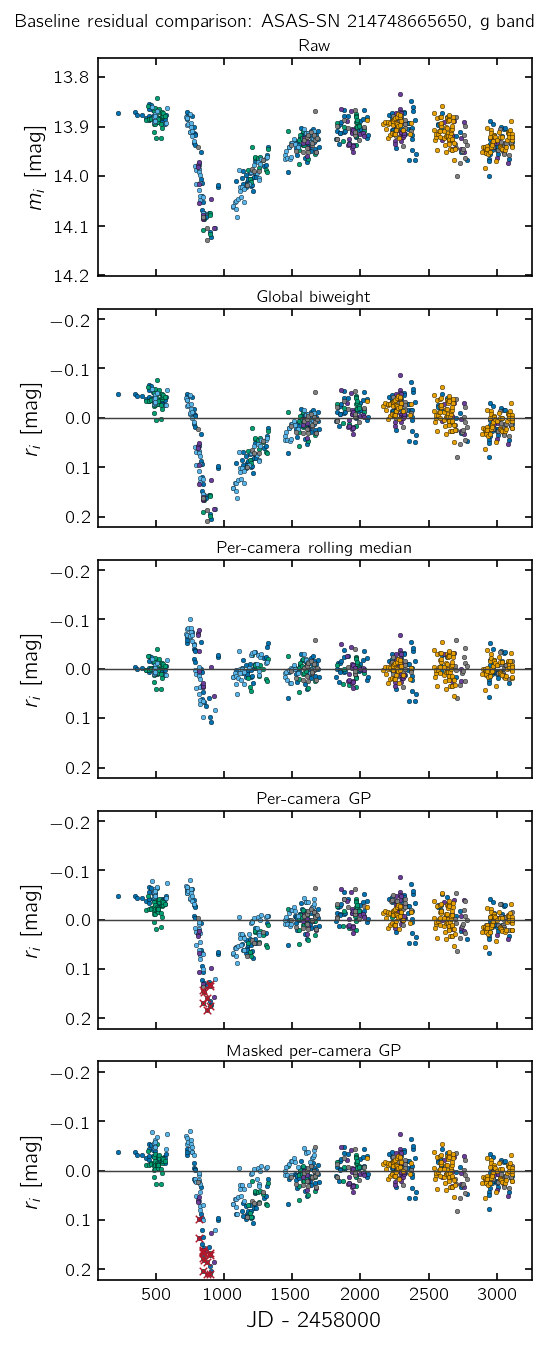

/Users/calder/code/malca/output/pdf/baseline_methods/illustrative/baseline_residual_methods_214748665650_g.pdf
/Users/calder/code/malca/output/pdf/baseline_methods/illustrative/baseline_residual_methods_214748665650_g.png


In [3]:
CAMERA_PALETTE = ('#0072B2', '#009E73', '#56B4E9', '#6A3D9A', '#7F7F7F', '#E69F00')
camera_order = sorted(lightcurve['camera#'].dropna().unique(), key=str)
CAMERA_COLORS = {camera: CAMERA_PALETTE[i % len(CAMERA_PALETTE)] for i, camera in enumerate(camera_order)}

def plot_camera_points(ax, frame, y_col, *, alpha=1.0, masked_col=None):
    for camera, sub in frame.groupby('camera#', sort=True):
        sub = sub.sort_values('JD')
        x = sub['JD'].to_numpy(float) - JD_OFFSET
        color = CAMERA_COLORS[camera]
        ax.scatter(
            x, sub[y_col], s=5, alpha=alpha, color=color,
            edgecolors='black', linewidths=0.18, label=f'camera {camera}',
        )
        if masked_col is not None:
            masked = sub[masked_col].fillna(False).to_numpy(bool)
            if masked.any():
                ax.scatter(x[masked], sub.loc[masked, y_col], s=13, marker='x', color='#b2182b', linewidths=0.7, zorder=5)

with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(
        5, 1, figsize=(FIG_SINGLE_COL_WIDTH, 9.0), sharex=True,
        gridspec_kw={'height_ratios': [1, 1, 1, 1, 1]},
    )

    residual_values = np.concatenate([
        pd.to_numeric(result['resid'], errors='coerce').to_numpy(float)
        for result in baseline_results.values()
    ])
    residual_values = residual_values[np.isfinite(residual_values)]
    raw_values = pd.to_numeric(lightcurve['mag'], errors='coerce').to_numpy(float)
    raw_values = raw_values[np.isfinite(raw_values)]
    raw_center = 0.5 * (float(np.min(raw_values)) + float(np.max(raw_values)))
    raw_half_span = 0.5 * (float(np.max(raw_values)) - float(np.min(raw_values))) * 1.05
    vertical_limit = max(0.15, float(np.max(np.abs(residual_values))) * 1.05, raw_half_span)

    plot_camera_points(axes[0], lightcurve, 'mag')
    axes[0].set_ylim(raw_center + vertical_limit, raw_center - vertical_limit)
    axes[0].set_ylabel(r'$m_i$ [mag]')
    axes[0].set_title('Raw', fontsize=8, pad=3)

    for ax, (name, result) in zip(axes[1:], baseline_results.items()):
        plot_frame = result.copy()
        plot_frame['event_mask'] = event_masks[name]
        plot_camera_points(ax, plot_frame, 'resid', masked_col='event_mask')
        ax.axhline(0, color='0.25', lw=0.7)
        ax.set_ylim(vertical_limit, -vertical_limit)
        ax.set_ylabel(r'$r_i$ [mag]')
        ax.set_title(name, fontsize=8, pad=3)
        ax.tick_params(direction='in', top=True, right=True)

    axes[-1].set_xlabel('JD - 2458000')
    axes[0].tick_params(direction='in', top=True, right=True)
    fig.suptitle(f'Baseline residual comparison: ASAS-SN {TARGET_ID}, g band', fontsize=9)
    finalize_publication_figure(fig, rect=(0, 0, 1, 0.982))
    fig.savefig(PDF_PATH)
    fig.savefig(PNG_PATH, dpi=300)
    plt.show()

print(PDF_PATH)
print(PNG_PATH)
